# 🌿 Árbol de la Vida — Sistema Hídrico de Paraguay
### Río Paraguay: Visualización en Colores Neón

Este cuaderno descarga datos de ríos globales (Natural Earth 10m),
extrae la red hídrica conectada al **Río Paraguay** y la renderiza
como un **árbol de la vida** con ramificaciones en colores neón sobre fondo negro.

**¿Por qué el Río Paraguay?**
- Es el río más importante del país y le da su nombre
- Atraviesa Paraguay de norte a sur (~2.621 km de longitud total)
- Define la frontera con Argentina al sur
- Su cuenca cubre prácticamente todo el territorio nacional
- Tiene innumerables afluentes que forman una red dendrítica espectacular

## 1. Instalación de dependencias

In [38]:
!pip install contextily --quiet

import os
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
from shapely.geometry import LineString, MultiLineString
from PIL import Image, ImageDraw, ImageFilter, ImageChops
import warnings
warnings.filterwarnings('ignore')

## 2. Descarga de datos de ríos (Natural Earth 10m)

In [39]:
# URL funcional de Natural Earth
!wget -q "https://naciscdn.org/naturalearth/10m/physical/ne_10m_rivers_lake_centerlines.zip" \
     -O ne_10m_rivers_lake_centerlines.zip

!unzip -o ne_10m_rivers_lake_centerlines.zip -d rivers_data/

# Cargar el shapefile
gdf_rivers = gpd.read_file('rivers_data/ne_10m_rivers_lake_centerlines.shp')

print(f"✅ Ríos cargados: {len(gdf_rivers)} segmentos")
print(f"Columnas disponibles: {list(gdf_rivers.columns)}")
print(f"\nAlgunos ríos en la región:")

# Filtrar por región de Sudamérica para ver qué ríos hay
sa_bbox = gdf_rivers.cx[-75:-55, -35:5]
print(sa_bbox[['name','scalerank']].dropna().sort_values('scalerank').head(20))

Archive:  ne_10m_rivers_lake_centerlines.zip
  inflating: rivers_data/ne_10m_rivers_lake_centerlines.README.html  
 extracting: rivers_data/ne_10m_rivers_lake_centerlines.VERSION.txt  
 extracting: rivers_data/ne_10m_rivers_lake_centerlines.cpg  
  inflating: rivers_data/ne_10m_rivers_lake_centerlines.dbf  
  inflating: rivers_data/ne_10m_rivers_lake_centerlines.prj  
  inflating: rivers_data/ne_10m_rivers_lake_centerlines.shp  
  inflating: rivers_data/ne_10m_rivers_lake_centerlines.shx  
✅ Ríos cargados: 1473 segmentos
Columnas disponibles: ['dissolve', 'scalerank', 'featurecla', 'name', 'name_alt', 'rivernum', 'note', 'min_zoom', 'name_en', 'min_label', 'ne_id', 'label', 'wikidataid', 'name_ar', 'name_bn', 'name_de', 'name_es', 'name_fr', 'name_el', 'name_hi', 'name_hu', 'name_id', 'name_it', 'name_ja', 'name_ko', 'name_nl', 'name_pl', 'name_pt', 'name_ru', 'name_sv', 'name_tr', 'name_vi', 'name_zh', 'name_fa', 'name_he', 'name_uk', 'name_ur', 'name_zht', 'geometry']

Algunos ríos e

## 3. Diagnóstico: Nombres de ríos existen en la región de Paraguay

In [40]:
# Paraguay: longitud -62.6 a -54.2, latitud -27.6 a -19.3
PARAGUAY_LON = (-63.0, -54.0)
PARAGUAY_LAT = (-28.0, -19.0)

region = gdf_rivers.cx[
    PARAGUAY_LON[0]:PARAGUAY_LON[1],
    PARAGUAY_LAT[0]:PARAGUAY_LAT[1]
]

print(f"Ríos encontrados en el  Paraguay: {len(region)}")
print("\nTodos los nombres únicos:")
print(region['name'].dropna().sort_values().unique())
print("\nDetalle con scalerank:")
print(region[['name', 'scalerank']].sort_values('scalerank').to_string())

Ríos encontrados en el  Paraguay: 12

Todos los nombres únicos:
['Bermejo' 'Ivinheima' 'Jejuí Guazú' 'Miranda' 'Paraná' 'Pilcomayo'
 'Taquari' 'Uruguay' 'Verde']

Detalle con scalerank:
            name  scalerank
733       Paraná          2
648       Paraná          4
649       Paraná          4
572      Uruguay          6
573    Pilcomayo          6
255      Bermejo          8
120         None          8
253    Ivinheima          8
35       Miranda          9
37       Taquari          9
39         Verde          9
103  Jejuí Guazú          9


✅ Semilla seleccionada por: río más importante  (scalerank=2, nombre='Paraná') — usado como semilla
   Segmentos: 1
   Nombres: ['Paraná']
   Scalerank: [2]


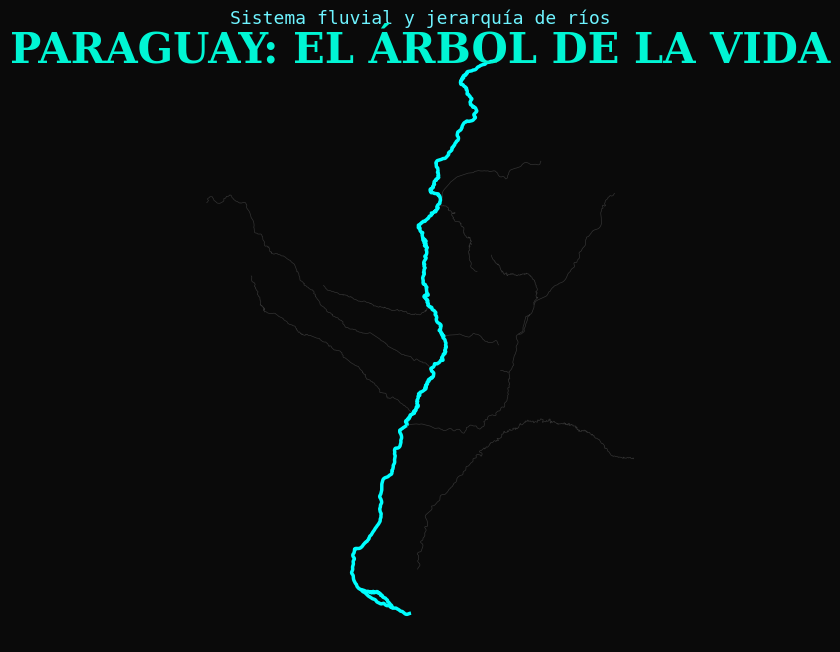

Bounding box: [-60.76933594 -34.04900482 -55.07529297 -14.29143646]


In [41]:
# ─── ESTRATEGIA ROBUSTA DE SELECCIÓN DE SEMILLA ───
# Usamos una jerarquía de fallbacks:
#   1) Buscar por nombre exacto 'Paraguay'
#   2) Buscar cualquier variante que contenga 'Paraguay'
#   3) Usar el río con scalerank más bajo

PARAGUAY_LON = (-63.0, -54.0)
PARAGUAY_LAT = (-28.0, -19.0)

region = gdf_rivers.cx[
    PARAGUAY_LON[0]:PARAGUAY_LON[1],
    PARAGUAY_LAT[0]:PARAGUAY_LAT[1]
]

seed = None
metodo = ""

# Nombre exacto
for nombre in ['Paraguay', 'Río Paraguay', 'Rio Paraguay', 'río Paraguay']:
    r = gdf_rivers[gdf_rivers['name'] == nombre]
    if len(r) > 0:
        seed = r
        metodo = f"nombre exacto '{nombre}'"
        break

# Nombre parcial
if seed is None or len(seed) == 0:
    r = region[region['name'].str.contains('Paraguay', case=False, na=False)]
    if len(r) > 0:
        seed = r
        metodo = "búsqueda parcial 'Paraguay'"

# El río de mayor importancia
if seed is None or len(seed) == 0:
    best_rank = region['scalerank'].min()
    seed = region[region['scalerank'] == best_rank]
    metodo = f"río más importante  (scalerank={best_rank}, nombre='{seed['name'].values[0]}') — usado como semilla"

print(f"✅ Semilla seleccionada por: {metodo}")
print(f"   Segmentos: {len(seed)}")
print(f"   Nombres: {seed['name'].unique()}")
print(f"   Scalerank: {seed['scalerank'].unique()}")

# Visualización rápida
if len(seed) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(5, 7))
    fig.patch.set_facecolor('#0a0a0a')
    ax.set_facecolor('#0a0a0a')
    region.plot(ax=ax, color='#333333', linewidth=0.5)
    seed.plot(ax=ax, color='cyan', linewidth=2.5)
    fig.text(
        0.5, 0.955,
        "Sistema fluvial y jerarquía de ríos",
        ha="center",
        va="center",
        fontsize=13,
        color="#6EF3FF",
        fontfamily="monospace"
    )
    fig.text(
        0.5, 0.910,
        "PARAGUAY: EL ÁRBOL DE LA VIDA",
        ha="center",
        va="center",
        fontsize=30,
        color="#00F5D4",
        fontweight="bold",
        fontfamily="serif",
    )
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    print(f"Bounding box: {seed.total_bounds}")
else:
    print("❌ No se encontró ningún río. Revisa el dataset descargado.")

### 4. Función de conectividad de ríos

In [42]:
def get_connected_river_system(rivers_gdf, seed_gdf, gap=500):
    """
    Extrae todos los segmentos de río conectados a la semilla (seed_gdf)
    dentro de una tolerancia espacial (gap, en metros si está en EPSG:3857).

    """
    # Mismo CRS
    rivers_gdf = rivers_gdf.copy().to_crs(3857)
    seed_gdf = seed_gdf.copy().to_crs(3857)

    # Índice
    sindex = rivers_gdf.sindex

    connected = set(seed_gdf.index)
    frontier = list(seed_gdf.index)

    while frontier:
        idx = frontier.pop()
        geom = rivers_gdf.loc[idx, 'geometry']

        geom_buffer = geom.buffer(gap)
        candidates = list(sindex.intersection(geom_buffer.bounds))
        candidates = [c for c in candidates if c not in connected]

        for c in candidates:
            other = rivers_gdf.loc[c, 'geometry']
            if geom_buffer.intersects(other):
                connected.add(c)
                frontier.append(c)

    return rivers_gdf.loc[list(connected)].to_crs(4326)


## 5. Extraer la cuenca del Río Paraguay

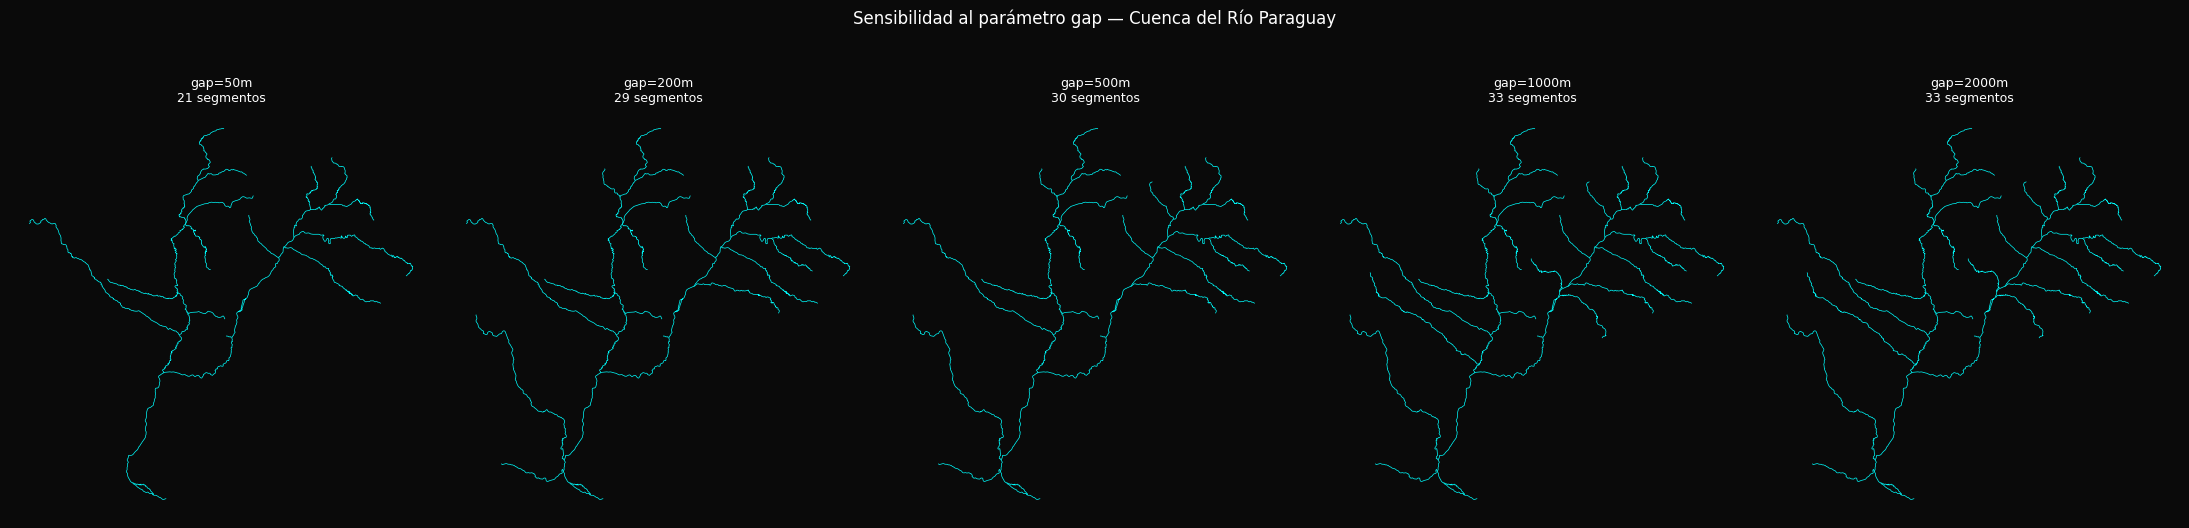

In [43]:

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.patch.set_facecolor('#0a0a0a')

for i, gap in enumerate([50, 200, 500, 1000, 2000]):
    sistema = get_connected_river_system(gdf_rivers.to_crs(3857), seed, gap=gap)
    sistema.plot(ax=axes[i], color='cyan', linewidth=0.5)
    axes[i].set_title(f'gap={gap}m\n{len(sistema)} segmentos',
                      color='white', fontsize=9)
    axes[i].axis('off')
    axes[i].set_facecolor('#0a0a0a')

plt.suptitle('Sensibilidad al parámetro gap — Cuenca del Río Paraguay',
             color='white', fontsize=12)
plt.tight_layout()
plt.show()

In [44]:
# Extraer sistema final con gap óptimo
GAP_OPTIMO = 1000

paraguay_system = get_connected_river_system(
    gdf_rivers.to_crs(3857),
    seed,
    gap=GAP_OPTIMO
)

print(f"✅ Sistema hídrico del Río Paraguay: {len(paraguay_system)} segmentos")
print(f"Rango scalerank: {paraguay_system['scalerank'].min()} - {paraguay_system['scalerank'].max()}")

✅ Sistema hídrico del Río Paraguay: 33 segmentos
Rango scalerank: 2 - 9


### 5.  Renderizado «Árbol de la Vida»

In [45]:
def get_neon_color_by_rank(scalerank):

    if scalerank <= 2:
        return (0, 255, 255)      # Cian — tronco principal
    elif scalerank <= 4:
        return (0, 255, 100)      # Verde neón — ramas grandes
    elif scalerank <= 6:
        return (255, 0, 200)      # Magenta — ramas medianas
    elif scalerank <= 8:
        return (255, 140, 0)      # Naranja neón — ramas pequeñas
    else:
        return (255, 255, 0)      # Amarillo — capilares


def render_tree_of_life_neon(
    river_gdf,
    base_width=3000,
    pad=0.08,
    bg_color=(0, 0, 0),
    glow_passes=4,
    max_glow_blur=40,
    output_path=None
):

    # ─── STEP 1: Reproyectar a Web Mercator ───
    river_gdf = river_gdf.to_crs(3857)

    # ─── STEP 2: Bounding box con padding ───
    minx, miny, maxx, maxy = river_gdf.total_bounds

    dx = (maxx - minx) * pad
    dy = (maxy - miny) * pad

    minx -= dx;  maxx += dx
    miny -= dy;  maxy += dy

    width_m  = maxx - minx
    height_m = maxy - miny

    # ─── STEP 3: Tamaño de imagen ───
    W = base_width
    H = int(W * (height_m / width_m))
    print(f"Tamaño de imagen: {W} x {H} px")

    # ─── STEP 4: Función de conversión coordenadas → píxeles ───
    def geo_to_pixel(x, y):
        px = (x - minx) / width_m  * W
        py = (maxy - y) / height_m * H
        return int(px), int(py)

    # ─── STEP 5: Canvas base negro ───
    img = Image.new("RGB", (W, H), bg_color)

    # ─── STEP 6: Determinar scalerank disponible ───
    has_sr = 'scalerank' in river_gdf.columns
    sr_values = list(river_gdf['scalerank'] if has_sr else [5] * len(river_gdf))

    # ─── STEP 7: Capas de resplandor (de afuera hacia adentro) ───
    blur_radii  = [max_glow_blur, max_glow_blur//2, max_glow_blur//4, max_glow_blur//8]
    alpha_vals  = [60, 100, 150, 200]
    width_mults = [4.0, 2.5, 1.5, 1.0]

    for pass_idx in range(glow_passes):
        layer = Image.new("RGBA", (W, H), (0, 0, 0, 0))
        draw  = ImageDraw.Draw(layer, "RGBA")

        blur   = blur_radii[pass_idx]
        alpha  = alpha_vals[pass_idx]
        w_mult = width_mults[pass_idx]

        for geom, sr in zip(river_gdf.geometry, sr_values):

            lines = []
            if isinstance(geom, LineString):
                lines = [geom]
            elif isinstance(geom, MultiLineString):
                lines = list(geom.geoms)

            r, g, b = get_neon_color_by_rank(int(sr) if sr is not None else 5)

            line_width = max(1, int((12 - int(sr)) * w_mult)) if sr is not None else int(3 * w_mult)

            for line in lines:
                pts = [geo_to_pixel(x, y) for x, y in line.coords]
                if len(pts) >= 2:
                    draw.line(pts, fill=(r, g, b, alpha), width=line_width)

        if blur > 0:
            layer = layer.filter(ImageFilter.GaussianBlur(blur))

        img_rgba = img.convert("RGBA")
        img_rgba = Image.alpha_composite(img_rgba, layer)
        img = img_rgba.convert("RGB")

    # ─── STEP 8: Línea de núcleo
    core_layer = Image.new("RGBA", (W, H), (0, 0, 0, 0))
    core_draw  = ImageDraw.Draw(core_layer, "RGBA")

    for geom, sr in zip(river_gdf.geometry, sr_values):
        lines = []
        if isinstance(geom, LineString):
            lines = [geom]
        elif isinstance(geom, MultiLineString):
            lines = list(geom.geoms)

        r, g, b = get_neon_color_by_rank(int(sr) if sr is not None else 5)
        core_width = max(1, int(5 - int(sr) * 0.4)) if sr is not None else 2

        for line in lines:
            pts = [geo_to_pixel(x, y) for x, y in line.coords]
            if len(pts) >= 2:

                core_draw.line(pts, fill=(255, 255, 255, 255), width=max(1, core_width - 1))

                core_draw.line(pts, fill=(r, g, b, 230), width=core_width)

    img_rgba = img.convert("RGBA")
    img_rgba = Image.alpha_composite(img_rgba, core_layer)
    img      = img_rgba.convert("RGB")

    if output_path:
        img.save(output_path, dpi=(300, 300))
        print(f"✅ Imagen guardada en: {output_path}")

    return img


print("✅ Función de renderizado neón definida")

✅ Función de renderizado neón definida


## 6.  Generar el Árbol de la Vida

Renderizando el Árbol de la Vida del Río Paraguay...
Tamaño de imagen: 3000 x 2922 px
✅ Imagen guardada en: paraguay_arbol_vida_neon.png


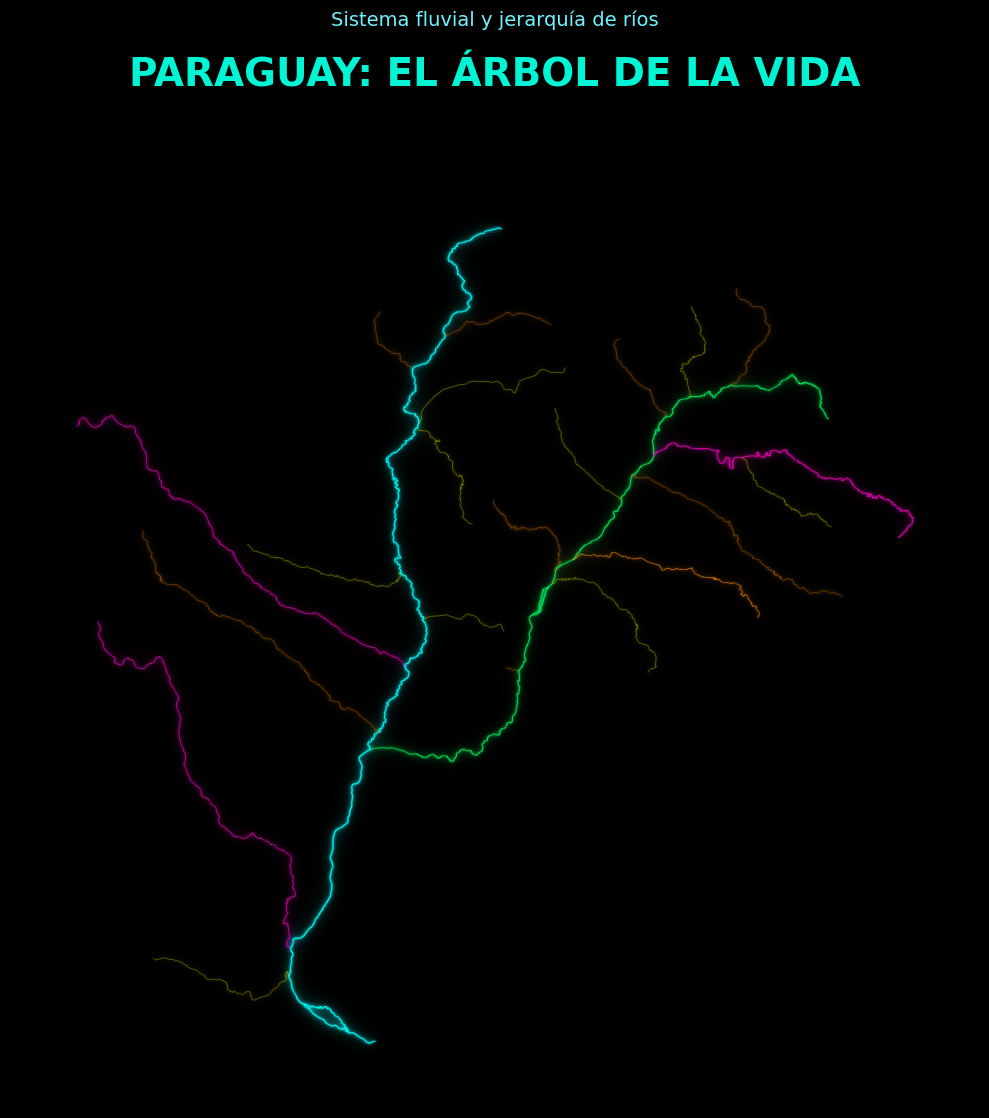

In [46]:
print("Renderizando el Árbol de la Vida del Río Paraguay...")

img_arbol = render_tree_of_life_neon(
    paraguay_system,
    base_width=3000,
    pad=0.08,
    bg_color=(0, 0, 0),
    glow_passes=4,
    max_glow_blur=40,
    output_path='paraguay_arbol_vida_neon.png'
)

fig, ax = plt.subplots(1, 1, figsize=(10, 14))
ax.imshow(img_arbol)
ax.axis('off')
fig.text(
    0.5, 0.94,
    "Sistema fluvial y jerarquía de ríos",
    ha="center",
    va="center",
    fontsize=14,
    color="#6EF3FF"
)
fig.text(
    0.5, 0.90,
    "PARAGUAY: EL ÁRBOL DE LA VIDA",
    ha="center",
    va="center",
    fontsize=28,
    color="#00F5D4",
    fontweight="bold"
)
fig.patch.set_facecolor('black')
plt.tight_layout()
plt.show()

## 8. Variante: Árbol sobre mapa oscuro

In [47]:
import random
import math
import os
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
from PIL import Image, ImageDraw, ImageFilter, ImageFont, ImageChops
from shapely.geometry import LineString, MultiLineString
from google.colab import files

def build_cinematic_genesis_gif(
    river_gdf,
    output_path='paraguay_arbol_vida.gif',
    base_width=1200,
    fps=14,
    n_wave_frames=70,
    n_pulse_frames=15,
    n_hold_frames=15,
    autor='Mónica Gómez',
    titulo='PARAGUAY: EL ÁRBOL DE LA VIDA',
):
    # ── 1. SETUP GEOMÉTRICO ───────────────────────────────────────
    riv = river_gdf.to_crs(3857).copy().reset_index(drop=True)
    minx, miny, maxx, maxy = riv.total_bounds
    pad = 0.08
    dx, dy = (maxx - minx) * pad, (maxy - miny) * pad
    minx -= dx
    maxx += dx
    miny -= dy
    maxy += dy
    wm, hm = maxx - minx, maxy - miny

    W = base_width
    H = int(W * hm / wm)
    cx_px, cy_px = W // 2, H // 2
    max_dist = math.hypot(W, H)

    def g2p(x, y):
        return int((x - minx) / wm * W), int((maxy - y) / hm * H)

    # ── 2. BASEMAP ───────────────────────────────────────────────

    fig, ax = plt.subplots(figsize=(W / 300, H / 300), dpi=300)
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    fig.patch.set_facecolor("#061226")
    ax.set_facecolor("#061226")
    ax.axis('off')
    ctx.add_basemap(ax, crs=riv.crs.to_string(), source=ctx.providers.CartoDB.DarkMatterNoLabels)
    fig.tight_layout(pad=0)
    fig.canvas.draw()
    basemap_arr = np.asarray(fig.canvas.renderer.buffer_rgba())
    plt.close(fig)
    basemap_img = Image.fromarray(basemap_arr).convert("RGBA").resize((W, H), Image.LANCZOS)

    # ── 3. PRE-CALCULAR SEGMENTOS ─────────────────────────────────
    seg_data = []
    for idx, row in riv.iterrows():
        geom = row['geometry']
        lines = [geom] if isinstance(geom, LineString) else list(geom.geoms) if isinstance(geom, MultiLineString) else []
        pts_list = [[g2p(x, y) for x, y in l.coords] for l in lines if not l.is_empty]
        if pts_list:
            flat = [p for pts in pts_list for p in pts]
            d = math.hypot(sum(p[0] for p in flat)/len(flat) - cx_px,
                           sum(p[1] for p in flat)/len(flat) - cy_px)
            seg_data.append((idx, d, row.get('scalerank', 5), pts_list))
    seg_data.sort(key=lambda x: x[1])

    # ── 4. FUNCIÓN OVERLAY ───────────────────────────────────────
    def apply_ui_overlay(canvas_img):
        draw = ImageDraw.Draw(canvas_img, "RGBA")
        try:
            f_path = "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf"
            f_title = ImageFont.truetype(f_path, int(H * 0.045))
            f_sub   = ImageFont.truetype(f_path, int(H * 0.020))
            f_leg_tit = ImageFont.truetype(f_path, int(H * 0.020))
            f_leg_txt = ImageFont.truetype(f_path, int(H * 0.018))
        except:
            f_title = f_sub = f_leg_tit = f_leg_txt = ImageFont.load_default()

        # ── BLOQUE TÍTULO ──────────────────

        title_bg_h = int(H * 0.16)
        draw.rectangle([(0, 0), (W, title_bg_h)],
                       fill=(0, 0, 0, 90))

        draw.text((W//2, int(H * 0.040)),
                  "Sistema fluvial y jerarquía de ríos",
                  font=f_sub, fill=(110, 243, 255, 180), anchor="mm")


        sep_w = int(W * 0.32)
        draw.line([(W//2 - sep_w//2, int(H * 0.068)),
                   (W//2 + sep_w//2, int(H * 0.068))],
                  fill=(0, 245, 212, 160), width=2)


        draw.text((W//2, int(H * 0.105)),
                  titulo,
                  font=f_title, fill=(0, 245, 212, 255), anchor="mm")

        # ── LEYENDA  ───────────────────
        box_w, box_h = int(W * 0.28), int(H * 0.16)
        box_x, box_y = int(W * 0.03), H - box_h - int(H * 0.07)
        draw.rounded_rectangle([box_x, box_y, box_x + box_w, box_y + box_h],
                               radius=10, fill=(11, 31, 58, 220),
                               outline=(0, 245, 212, 200), width=2)

        lx, ly = box_x + 15, box_y + 15
        draw.text((lx, ly), "Jerarquía de ríos", font=f_leg_tit, fill=(0, 245, 212, 255))
        items = [((0, 245, 212),  "— Río principal"),
                 ((0, 255, 110),  "— Afluentes mayores"),
                 ((255, 55, 175), "— Red secundaria")]
        ly += int(H * 0.035)
        for color, txt in items:
            draw.text((lx, ly), txt, font=f_leg_txt, fill=(*color, 255))
            ly += int(H * 0.028)


        draw.text((W - int(W * 0.04), H - int(H * 0.055)),
                  f"Data: Natural Earth  ·  {autor}",
                  font=f_sub, fill=(180, 220, 255, 160), anchor="ra")

    # ── 5. GENERACIÓN DE FRAMES ───────────────────────────────────
    frames = []
    for f in range(n_wave_frames + n_pulse_frames + n_hold_frames):
        glow_layer = Image.new("RGBA", (W, H), (0, 0, 0, 0))
        gd = ImageDraw.Draw(glow_layer, "RGBA")
        t = min(1.0, f / (n_wave_frames - 1)) if n_wave_frames > 0 else 1.0
        wave_r = max_dist * (1 - (1 - t) ** 2.2)
        for _, dist, sr, pts_list in seg_data:
            if dist <= wave_r:
                r, g, b = get_neon_color_by_rank(int(sr))
                for pts in pts_list:
                    gd.line(pts, fill=(r, g, b, 90),  width=max(6, int((14-sr)*2.5)))
                    gd.line(pts, fill=(r, g, b, 220), width=max(1, int((10-sr)*0.8)))

        glow_blurred = glow_layer.filter(ImageFilter.GaussianBlur(12))
        glow_final   = Image.alpha_composite(glow_blurred, glow_layer)
        frame_map    = ImageChops.screen(basemap_img.convert("RGB"),
                                         glow_final.convert("RGB")).convert("RGBA")
        apply_ui_overlay(frame_map)
        frames.append(frame_map.convert("RGB"))

    # ── 6. GUARDAR Y DESCARGAR ────────────────────────────────────
    frames_p = [f.quantize(colors=128) for f in frames]
    frames_p[0].save(output_path, save_all=True, append_images=frames_p[1:],
                     duration=int(1000/fps), loop=0, optimize=True)

    print(f"✅ Archivo listo. Iniciando descarga de {output_path}...")
    files.download(output_path)
    return output_path

# --- EJECUCIÓN DIRECTA ---
gif_final = build_cinematic_genesis_gif(
    river_gdf=paraguay_system,
    output_path='paraguay_arbol_vida.gif',
    autor='Mónica Gómez'
)

✅ Archivo listo. Iniciando descarga de paraguay_arbol_vida.gif...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>